# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
137,0.005383,-0.044642,0.049840,0.097615,-0.015328,-0.016345,-0.006584,-0.002592,0.017036,-0.013504,280.0
14,0.045341,-0.044642,-0.025607,-0.012556,0.017694,-0.000061,0.081775,-0.039493,-0.031988,-0.075636,118.0
358,-0.020045,-0.044642,-0.084886,-0.026328,-0.035968,-0.034194,0.041277,-0.051671,-0.082379,-0.046641,90.0
179,-0.023677,-0.044642,-0.015906,-0.012556,0.020446,0.041274,-0.043401,0.034309,0.014074,-0.009362,151.0
326,0.045341,0.050680,-0.008362,-0.033213,-0.007073,0.001191,-0.039719,0.034309,0.029935,0.027917,131.0
71,-0.001882,-0.044642,0.033673,0.125158,0.024574,0.026243,-0.010266,-0.002592,0.026717,0.061054,270.0
25,-0.067268,0.050680,-0.012673,-0.040099,-0.015328,0.004636,-0.058127,0.034309,0.019196,-0.034215,202.0
99,-0.001882,-0.044642,-0.064408,0.011544,0.027326,0.037517,-0.013948,0.034309,0.011785,-0.054925,83.0
330,0.009016,0.050680,0.030440,0.042529,-0.002945,0.036890,-0.065491,0.071210,-0.023647,0.015491,244.0
245,-0.027310,-0.044642,-0.035307,-0.029770,-0.056607,-0.058620,0.030232,-0.039493,-0.049872,-0.129483,125.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
valores_faltantes = data.isnull().sum()
print("numero de valores faltantes por columna:")
print(valores_faltantes)

numero de valores faltantes por columna:
age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64


### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [11]:
imputer_media = SimpleImputer(strategy='mean')
data['bmi'] = imputer_media.fit_transform(data[['bmi']])
print(f"Valores faltantes en 'bmi' tras la imputación: {data['bmi'].isnull().sum()}")

Valores faltantes en 'bmi' tras la imputación: 0


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [12]:
data_knn = data.copy()

knn_imputer = KNNImputer(n_neighbors=5)

columnas_a_imputar = ['bmi', 'bp']
data_knn[columnas_a_imputar] = knn_imputer.fit_transform(data_knn[columnas_a_imputar])

print("--- Comparacion de medidas---")
print(f"Media con SimpleImputer: {data['bmi'].mean():.6f}")
print(f"Media con KNNImputer:    {data_knn['bmi'].mean():.6f}")

--- Comparacion de medidas---
Media con SimpleImputer: -0.000205
Media con KNNImputer:    -0.000205


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

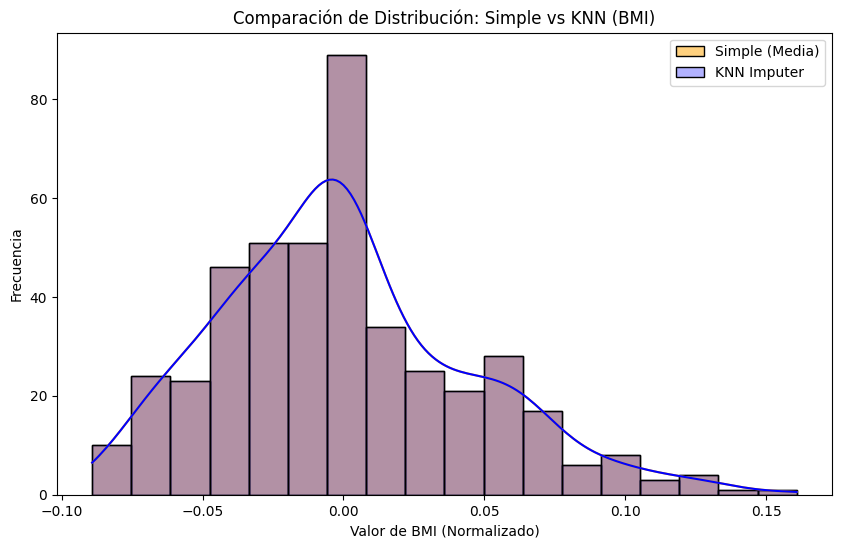

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(data['bmi'], color="orange", label="Simple (Media)", kde=True, alpha=0.5)
sns.histplot(data_knn['bmi'], color="blue", label="KNN Imputer", kde=True, alpha=0.3)

plt.title("Comparación de Distribución: Simple vs KNN (BMI)")
plt.xlabel("Valor de BMI (Normalizado)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()